# Electron Orbital Visualization Prototype

This notebook turns the electron orbital concepts into code.

## What this notebook demonstrates

- Wavefunctions and probability density.
- Quantum numbers.
- Nodes.
- Orbital cross-sections.
- Radial distribution functions.
- How the model maps to C++.

In [1]:
import math
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

# Use atomic units for visualization:
# a0 = 1
# hbar = 1
# e = 1

## 1. Wavefunction and probability density

An orbital is represented by a wavefunction:

$$
\psi(\mathbf{r})
$$

The probability density is:

$$
\rho(\mathbf{r}) = |\psi(\mathbf{r})|^2
$$

The visual shape of an orbital is usually an isosurface or cross-section of this probability density.

For an educational simulation, it is useful to separate the code into:

- a radial part,
- an angular part,
- a probability-density calculation,
- a visualization layer.

In [2]:
@dataclass
class Orbital:
    n: int
    l: int
    label: str


def total_nodes(n: int) -> int:
    return n - 1


def angular_nodes(l: int) -> int:
    return l


def radial_nodes(n: int, l: int) -> int:
    return n - l - 1


orbitals = [
    Orbital(1, 0, "1s"),
    Orbital(2, 0, "2s"),
    Orbital(2, 1, "2p"),
    Orbital(3, 2, "3d"),
    Orbital(4, 3, "4f"),
]

for orbital in orbitals:
    print(
        f"{orbital.label:>2}: "
        f"total nodes={total_nodes(orbital.n)}, "
        f"radial nodes={radial_nodes(orbital.n, orbital.l)}, "
        f"angular nodes={angular_nodes(orbital.l)}"
    )

1s: total nodes=0, radial nodes=0, angular nodes=0
2s: total nodes=1, radial nodes=1, angular nodes=0
2p: total nodes=1, radial nodes=0, angular nodes=1
3d: total nodes=2, radial nodes=0, angular nodes=2
4f: total nodes=3, radial nodes=0, angular nodes=3


## 2. Exact simple hydrogen orbitals

For hydrogen, several low-level orbitals have compact analytic forms.

In atomic units with $a_0 = 1$:

$$
\psi_{1s}(r) =
\frac{1}{\sqrt{\pi}}e^{-r}
$$

$$
\psi_{2s}(r) =
\frac{1}{4\sqrt{2\pi}}(2-r)e^{-r/2}
$$

$$
\psi_{2p_z}(r,\theta) =
\frac{1}{4\sqrt{2\pi}}r e^{-r/2}\cos\theta
$$

These are enough to show spherical shapes, radial nodes, p-orbital lobes, phase, and nodal planes.

In [3]:
def safe_r(x, y, z):
    return np.sqrt(x*x + y*y + z*z) + 1e-12


def psi_1s(x, y, z):
    r = safe_r(x, y, z)
    return (1.0 / math.sqrt(math.pi)) * np.exp(-r)


def psi_2s(x, y, z):
    r = safe_r(x, y, z)
    return (1.0 / (4.0 * math.sqrt(2.0 * math.pi))) * (2.0 - r) * np.exp(-r / 2.0)


def psi_2px(x, y, z):
    r = safe_r(x, y, z)
    return (1.0 / (4.0 * math.sqrt(2.0 * math.pi))) * x * np.exp(-r / 2.0)


def psi_2py(x, y, z):
    r = safe_r(x, y, z)
    return (1.0 / (4.0 * math.sqrt(2.0 * math.pi))) * y * np.exp(-r / 2.0)


def psi_2pz(x, y, z):
    r = safe_r(x, y, z)
    return (1.0 / (4.0 * math.sqrt(2.0 * math.pi))) * z * np.exp(-r / 2.0)

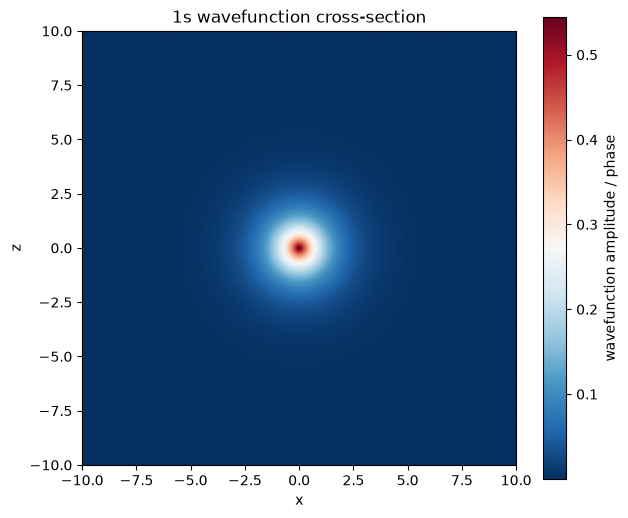

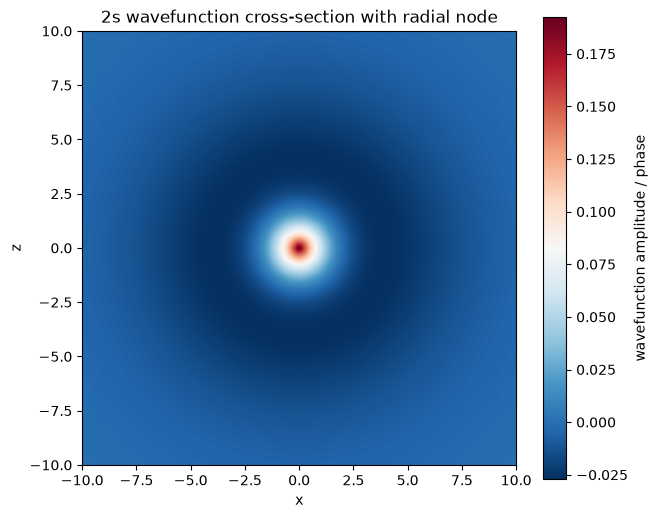

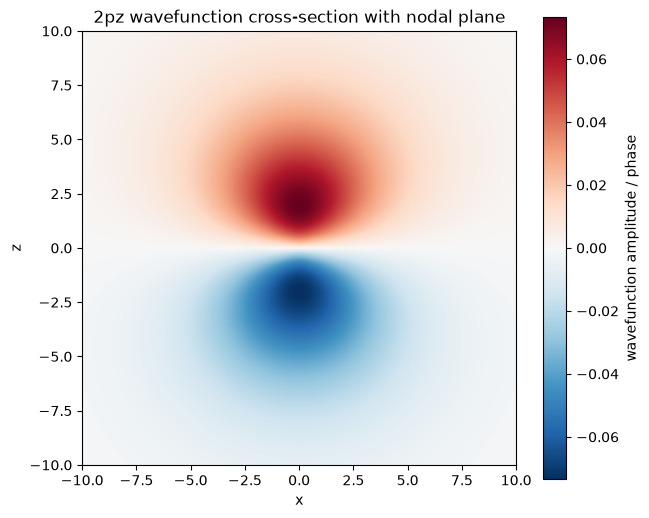

In [4]:
def make_grid(limit=10.0, points=400):
    axis = np.linspace(-limit, limit, points)
    X, Z = np.meshgrid(axis, axis)
    Y = np.zeros_like(X)
    return X, Y, Z


def plot_wavefunction_cross_section(func, title, limit=10.0):
    X, Y, Z = make_grid(limit=limit)
    psi = func(X, Y, Z)

    plt.figure(figsize=(7, 6))
    plt.imshow(
        psi,
        extent=[-limit, limit, -limit, limit],
        origin="lower",
        cmap="RdBu_r",
    )
    plt.colorbar(label="wavefunction amplitude / phase")
    plt.xlabel("x")
    plt.ylabel("z")
    plt.title(title)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()


plot_wavefunction_cross_section(psi_1s, "1s wavefunction cross-section")
plot_wavefunction_cross_section(psi_2s, "2s wavefunction cross-section with radial node")
plot_wavefunction_cross_section(psi_2pz, "2pz wavefunction cross-section with nodal plane")

## 3. Probability density

The probability density removes the sign of the wavefunction:

$$
\rho = |\psi|^2
$$

This is why different phase colors do not mean different electric charges. Opposite signs still produce positive probability density.

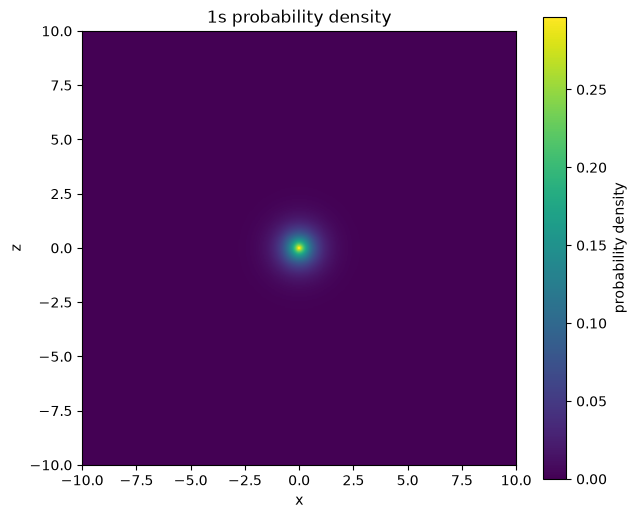

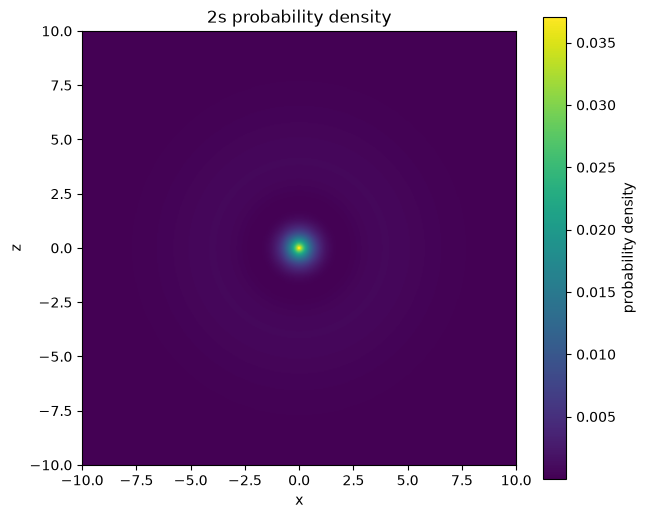

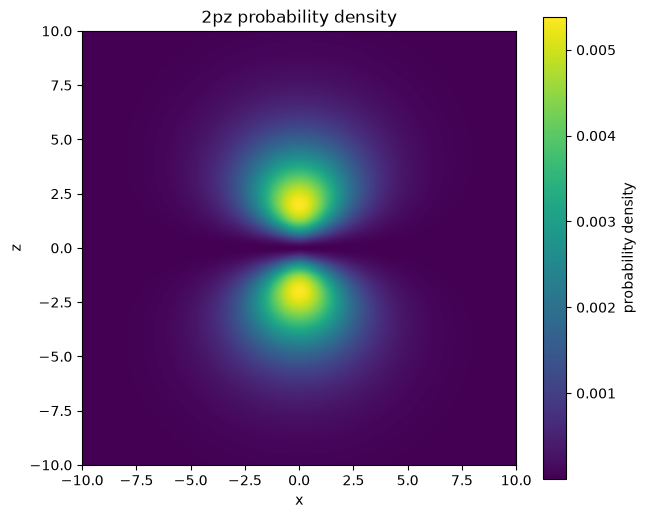

In [5]:
def plot_probability_density_cross_section(func, title, limit=10.0):
    X, Y, Z = make_grid(limit=limit)
    density = np.abs(func(X, Y, Z))**2

    plt.figure(figsize=(7, 6))
    plt.imshow(
        density,
        extent=[-limit, limit, -limit, limit],
        origin="lower",
        cmap="viridis",
    )
    plt.colorbar(label="probability density")
    plt.xlabel("x")
    plt.ylabel("z")
    plt.title(title)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()


plot_probability_density_cross_section(psi_1s, "1s probability density")
plot_probability_density_cross_section(psi_2s, "2s probability density")
plot_probability_density_cross_section(psi_2pz, "2pz probability density")

## 4. Approximate d orbital shapes

For an educational visualization, the angular shapes are often more important than exact normalization.

Simple real d-orbital angular forms can be modeled as:

$$
d_{xy} \propto xy
$$

$$
d_{xz} \propto xz
$$

$$
d_{yz} \propto yz
$$

$$
d_{x^2-y^2} \propto x^2-y^2
$$

$$
d_{z^2} \propto 3z^2-r^2
$$

We multiply these angular shapes by a decaying radial envelope for visualization.

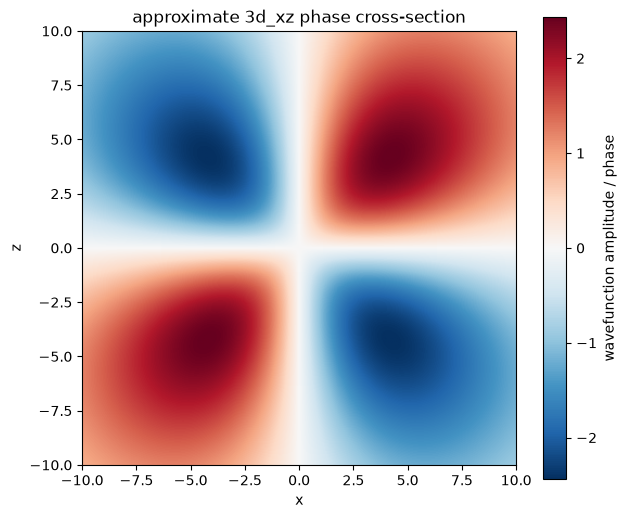

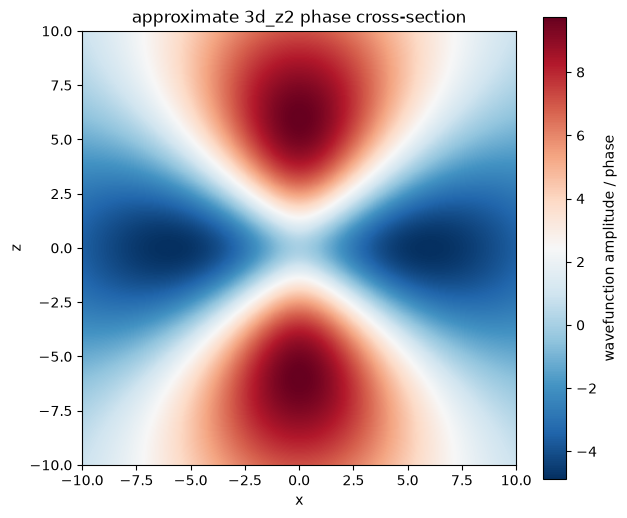

In [6]:
def radial_envelope(r, scale=3.0):
    return np.exp(-r / scale)


def psi_3d_xz(x, y, z):
    r = safe_r(x, y, z)
    return x * z * radial_envelope(r, scale=3.0)


def psi_3d_x2_y2(x, y, z):
    r = safe_r(x, y, z)
    return (x*x - y*y) * radial_envelope(r, scale=3.0)


def psi_3d_z2(x, y, z):
    r = safe_r(x, y, z)
    return (3*z*z - r*r) * radial_envelope(r, scale=3.0)


plot_wavefunction_cross_section(psi_3d_xz, "approximate 3d_xz phase cross-section")
plot_wavefunction_cross_section(psi_3d_z2, "approximate 3d_z2 phase cross-section")

## 5. Radial distribution functions

Probability density is probability per unit volume.

To ask how likely the electron is to be found at radius $r$, use the radial distribution function:

$$
P(r) = 4\pi r^2 |R(r)|^2
$$

For 1s, the probability density is largest at the nucleus, but the radial distribution is largest at one Bohr radius.

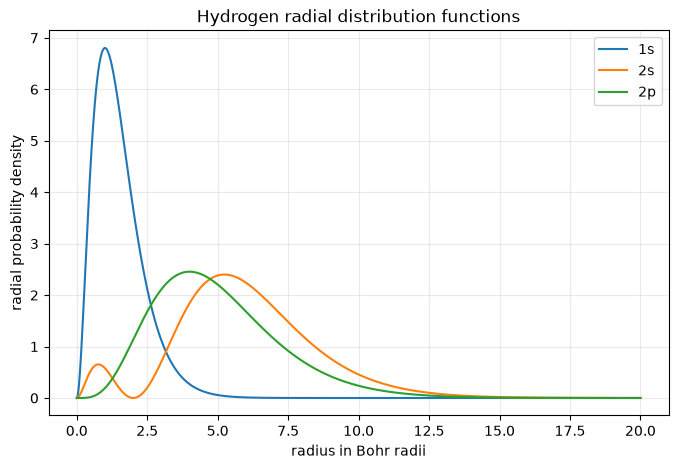

In [7]:
def R_1s(r):
    return 2.0 * np.exp(-r)


def R_2s(r):
    return (1.0 / (2.0 * math.sqrt(2.0))) * (2.0 - r) * np.exp(-r / 2.0)


def R_2p(r):
    return (1.0 / (2.0 * math.sqrt(6.0))) * r * np.exp(-r / 2.0)


r = np.linspace(0, 20, 1000)

distributions = {
    "1s": 4*np.pi*r**2*np.abs(R_1s(r))**2,
    "2s": 4*np.pi*r**2*np.abs(R_2s(r))**2,
    "2p": 4*np.pi*r**2*np.abs(R_2p(r))**2,
}

plt.figure(figsize=(8, 5))
for label, values in distributions.items():
    plt.plot(r, values, label=label)

plt.xlabel("radius in Bohr radii")
plt.ylabel("radial probability density")
plt.title("Hydrogen radial distribution functions")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 6. How this maps to C++

A C++ implementation can separate orbital identity from rendering.

```cpp
enum class OrbitalType {
    S,
    PX,
    PY,
    PZ,
    D_XY,
    D_XZ,
    D_YZ,
    D_X2_Y2,
    D_Z2
};

struct OrbitalParams {
    int n;
    int l;
    int m;
    OrbitalType type;
    double scale;
};

double probabilityDensity(const OrbitalParams& orbital, double x, double y, double z) {
    double psi = wavefunctionAmplitude(orbital, x, y, z);
    return psi * psi;
}
```

The simulation can expose controls for:

- orbital type,
- quantum numbers,
- phase view versus density view,
- cross-section plane,
- node display,
- probability threshold.